# Installs

In [1]:
!pip install --upgrade transformers datasets evaluate pycocotools torch torchvision ipywidgets widgetsnbextension timm 'accelerate>=0.26.0' albumentations torchmetrics

# Imports

In [2]:
import torch
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np

from collections import defaultdict
from datasets import load_dataset
from datasets import Dataset
from transformers import AutoModelForObjectDetection
from transformers import AutoImageProcessor
from transformers import TrainingArguments
from transformers import Trainer
from transformers import pipeline
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.nn.functional import softmax
from tqdm import tqdm
from PIL import Image, ImageDraw

# Constants

In [1]:
PREVIEW_ELEMENT_ID = 42

# Dataset

## Download dataset

In [2]:
all_classes = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle",
    "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone", "microwave", "oven",
    "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

all_classes_count = len(all_classes)

train_raw = load_dataset("detection-datasets/coco", split="train")
val_raw = load_dataset("detection-datasets/coco", split="val")

print("------------------------------------------------------------------")
print(all_classes_count)
print("------------------------------------------------------------------")
print(train_raw)
print(val_raw)
print("------------------------------------------------------------------")
print(train_raw[0])
print("------------------------------------------------------------------")

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

------------------------------------------------------------------
80
------------------------------------------------------------------
Dataset({
    features: ['image_id', 'image', 'width', 'height', 'objects'],
    num_rows: 117266
})
Dataset({
    features: ['image_id', 'image', 'width', 'height', 'objects'],
    num_rows: 4952
})
------------------------------------------------------------------
{'image_id': 9, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7F92C011AFB0>, 'width': 640, 'height': 480, 'objects': {'bbox_id': [1038967, 1039564, 1058555, 1534147, 1913551, 1913746, 1913856, 1914001], 'category': [45, 45, 50, 45, 49, 49, 49, 49], 'bbox': [[1.08, 187.69, 612.6700000000001, 473.53], [311.73, 4.31, 631.01, 232.99], [249.6, 229.27, 565.84, 474.35], [0.0, 13.51, 434.48, 388.63], [376.2, 40.36, 451.75, 86.89], [465.78, 38.97, 523.85, 85.64], [385.7, 73.66, 469.71999999999997, 144.17000000000002], [364.05, 2.49, 458.81, 73.55999999999999]], 'area'

In [3]:
all_class_count = {i: 0 for i in range(all_classes_count)}

for o in tqdm(train_raw):
    for c in o['objects']['category']:
        all_class_count[c]+=1

100%|██████████████████████████████████████████████████████████████████████████| 117266/117266 [05:10<00:00, 378.01it/s]


/tmp/ipykernel_706061/1243324176.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=90, ha='right')


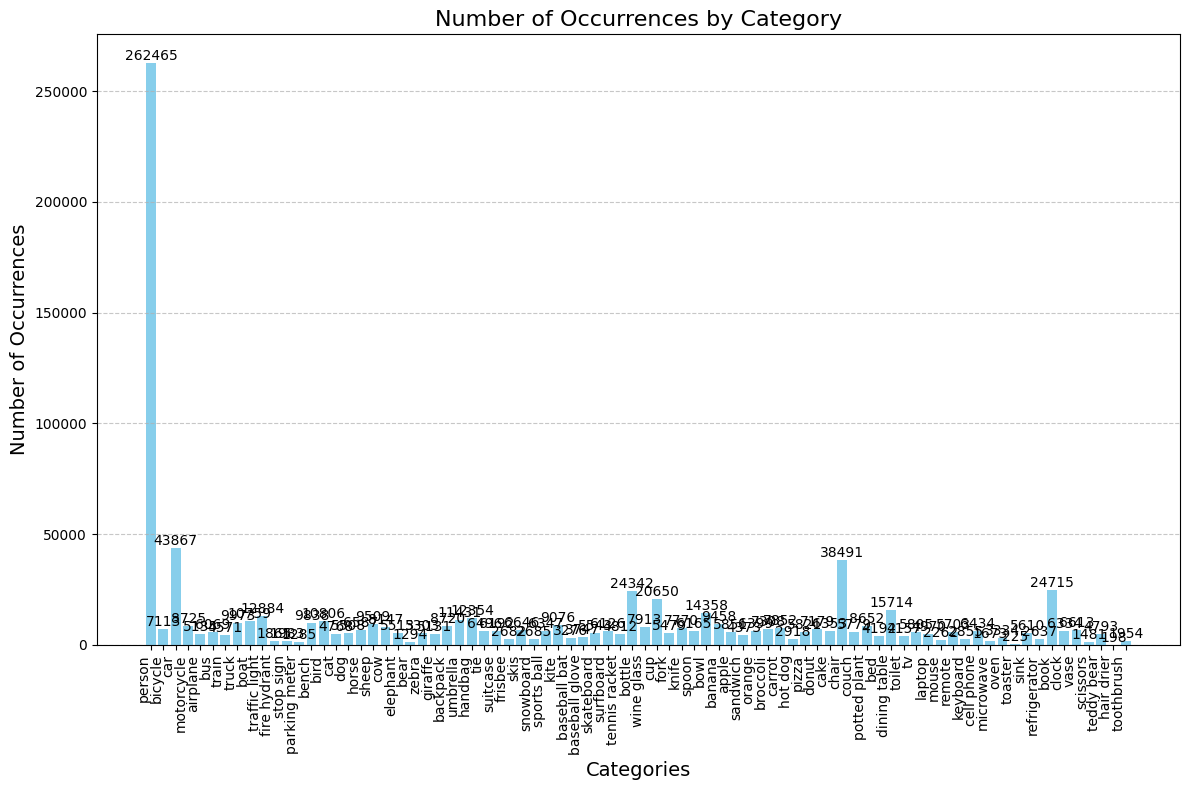

In [4]:
cats = list(all_classes)
vals = list(all_class_count.values())

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(cats, vals, color='skyblue')

ax.set_xlabel('Categories', fontsize=14)
ax.set_ylabel('Number of Occurrences', fontsize=14)
ax.set_title('Number of Occurrences by Category', fontsize=16)

ax.set_xticklabels(cats, rotation=90, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, height,
        f'{height}', ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

## Select classes

In [5]:
selected_classes = [
    "bicycle",
    "motorcycle",
    "airplane",
    "train",
    "bird",
    "cat",
    "dog",
    "horse",
    "cow",
    "elephant"
]

num_classes = len(selected_classes)

selected_ids = [all_classes.index(sel) for sel in selected_classes]
old2new_ids = {cid: i for i, cid in enumerate(selected_ids)}
new2old_ids = {i: cid for i, cid in enumerate(selected_ids)}

id2label = {i: selected_classes[i] for i in range(num_classes)}
label2id = {selected_classes[i]: i for i in range(num_classes)}

print(f"classes ({num_classes}): {selected_classes}")

print(f"selected_ids: {selected_ids}")
print(f"old2new_ids: {old2new_ids}")
print(f"new2old_ids: {new2old_ids}")

print(f"id2label: {id2label}")
print(f"label2id: {label2id}")

classes (10): ['bicycle', 'motorcycle', 'airplane', 'train', 'bird', 'cat', 'dog', 'horse', 'cow', 'elephant']
selected_ids: [1, 3, 4, 6, 14, 15, 16, 17, 19, 20]
old2new_ids: {1: 0, 3: 1, 4: 2, 6: 3, 14: 4, 15: 5, 16: 6, 17: 7, 19: 8, 20: 9}
new2old_ids: {0: 1, 1: 3, 2: 4, 3: 6, 4: 14, 5: 15, 6: 16, 7: 17, 8: 19, 9: 20}
id2label: {0: 'bicycle', 1: 'motorcycle', 2: 'airplane', 3: 'train', 4: 'bird', 5: 'cat', 6: 'dog', 7: 'horse', 8: 'cow', 9: 'elephant'}
label2id: {'bicycle': 0, 'motorcycle': 1, 'airplane': 2, 'train': 3, 'bird': 4, 'cat': 5, 'dog': 6, 'horse': 7, 'cow': 8, 'elephant': 9}


## Choose only selected classes

In [6]:
def clear_data(data):
    result = [];
    
    for rec in tqdm(data):
        new_rec = {
            'image_id': rec['image_id'],
            'image': rec['image'],
            'width': rec['width'],
            'height': rec['height'],
            'objects': {
                'bbox_id': [],
                'category': [],
                'bbox': [],
                'area': []
            }
        }
        
        l = len(rec['objects']['category'])
        for i in range(len(rec['objects']['category'])):
            ind = l - i - 1
            if (rec['objects']['category'][ind] in old2new_ids):
                new_rec['objects']['bbox_id'].append(rec['objects']['bbox_id'][ind])
                new_rec['objects']['category'].append(old2new_ids[rec['objects']['category'][ind]])
                new_rec['objects']['bbox'].append(rec['objects']['bbox'][ind][:])
                new_rec['objects']['area'].append(rec['objects']['area'][ind])

        if (len(new_rec['objects']['category']) > 0): result.append(new_rec)
            
    return Dataset.from_list(result)

train_filtred = clear_data(train_raw)
val_filtred   = clear_data(val_raw)

100%|██████████████████████████████████████████████████████████████████████████████| 4952/4952 [00:14<00:00, 345.04it/s]


In [59]:
print("------------------------------------------------------------------")
print(train_filtred[PREVIEW_ELEMENT_ID])
print("------------------------------------------------------------------")
print(val_filtred[PREVIEW_ELEMENT_ID])
print("------------------------------------------------------------------")
print(str(len(train_raw)) + " -> " + str(len(train_filtred)) + " (" + str(len(train_filtred)/len(train_raw)) + ")")
print("------------------------------------------------------------------")
print(str(len(val_raw)) + " -> " + str(len(val_filtred)) + " (" + str(len(val_filtred)/len(val_raw)) + ")")
print("------------------------------------------------------------------")

------------------------------------------------------------------
{'image_id': 757, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x427 at 0x7F8DED9D2DD0>, 'width': 640, 'height': 427, 'objects': {'area': [36693.03260000001, 24047.613750000004, 96110.0288], 'bbox': [[451.89, 0.96, 640.0, 420.29999999999995], [52.89, 52.41, 463.55, 349.58000000000004], [102.67, 18.3, 588.1999999999999, 427.0]], 'bbox_id': [584048, 583031, 581099], 'category': [9, 9, 9]}}
------------------------------------------------------------------
{'image_id': 19109, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x428 at 0x7F8DED9D2C50>, 'width': 640, 'height': 428, 'objects': {'area': [9083.0, 3163.526349999999, 1589.229399999998, 678.7150000000017, 385.6857499999986, 1958.5072499999997, 4308.7966000000015, 1670.7341499999998, 1508.619950000001, 3149.922050000001, 7753.239449999999, 3320.82665, 7202.677, 5968.806500000001], 'bbox': [[216.0, 234.0, 582.0, 350.0], [457.22, 2

In [11]:
train_class_count = {i: 0 for i in range(num_classes)}

for o in tqdm(train_filtred):
    for c in o['objects']['category']:
        train_class_count[c]+=1

100%|████████████████████████████████████████████████████████████████████████████| 29830/29830 [00:44<00:00, 670.30it/s]


/tmp/ipykernel_706061/96057952.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=90, ha='right')


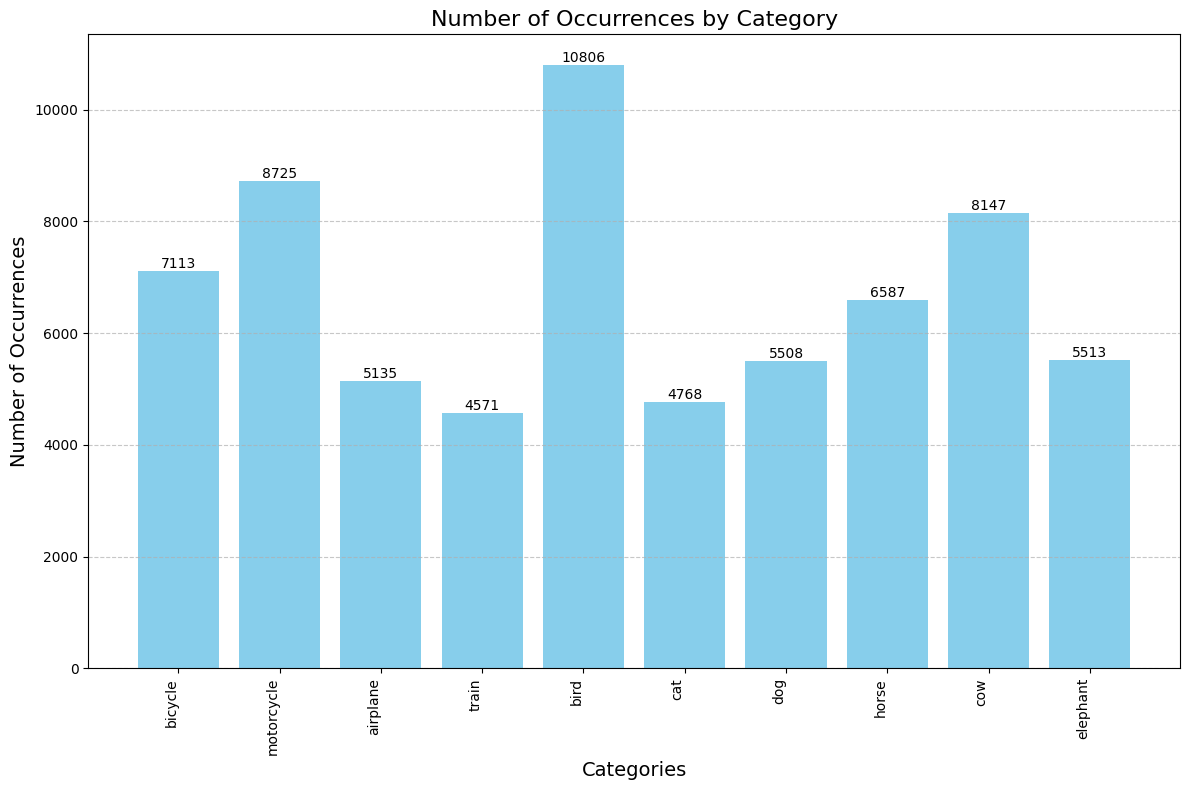

In [12]:
cats = list(selected_classes)
vals = list(train_class_count.values())

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(cats, vals, color='skyblue')

ax.set_xlabel('Categories', fontsize=14)
ax.set_ylabel('Number of Occurrences', fontsize=14)
ax.set_title('Number of Occurrences by Category', fontsize=16)

ax.set_xticklabels(cats, rotation=90, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, height,
        f'{height}', ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()
    

## Visualize dataset example

{'area': [36693.03260000001, 24047.613750000004, 96110.0288], 'bbox': [[451.89, 0.96, 640.0, 420.29999999999995], [52.89, 52.41, 463.55, 349.58000000000004], [102.67, 18.3, 588.1999999999999, 427.0]], 'bbox_id': [584048, 583031, 581099], 'category': [9, 9, 9]}


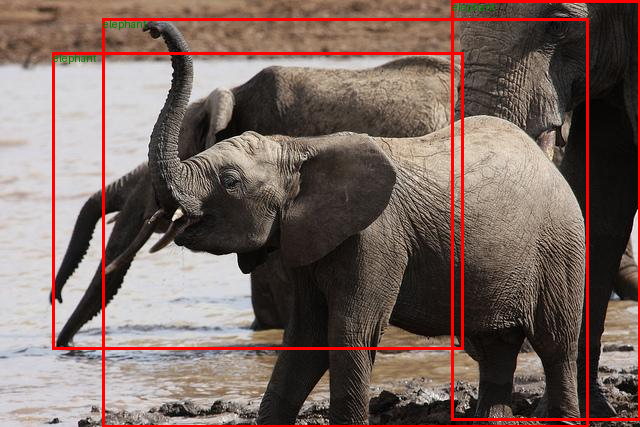

In [10]:
def draw_image_from_idx(dataset, idx):
    sample = dataset[idx]
    image = sample["image"]
    annotations = sample["objects"]
    draw = ImageDraw.Draw(image)
    width, height = sample["width"], sample["height"]

    print(annotations)

    for i in range(len(annotations["bbox_id"])):
        box = annotations["bbox"][i]
        x1, y1, x2, y2 = tuple(box)
        draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
        draw.text((x1, y1), id2label[annotations["category"][i]], fill="green")

    return image

draw_image_from_idx(dataset=train_filtred, idx=PREVIEW_ELEMENT_ID)

## Augmentations and Transformations

In [13]:
train_transform = A.Compose(
    [
        A.LongestMaxSize(500),
        A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.5),
        A.Rotate(limit=10, p=0.5),
        A.RandomScale(scale_limit=0.2, p=0.5),
        A.GaussianBlur(p=0.5),
        A.GaussNoise(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"]
    ),
)

val_transform = A.Compose(
    [
        A.LongestMaxSize(500),
        A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"]
    ),
)

/tmp/ipykernel_706061/1531974184.py:6: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
/tmp/ipykernel_706061/1531974184.py:24: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),


In [14]:
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [15]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations

def convert_voc_to_coco(bbox):
    xmin, ymin, xmax, ymax = bbox
    width = xmax - xmin
    height = ymax - ymin
    return [xmin, ymin, width, height]

def transform_aug_ann(examples, transform):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["category"])

        area.append(objects["area"])
        images.append(out["image"])

        converted_bboxes = [convert_voc_to_coco(bbox) for bbox in out["bboxes"]]
        bboxes.append(converted_bboxes)

        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

def transform_train(examples):
    return transform_aug_ann(examples, transform=train_transform)

def transform_val(examples):
    return transform_aug_ann(examples, transform=val_transform)


train = train_filtred.with_transform(transform_train)
val = val_filtred.with_transform(transform_val)

## Visualize dataset examples with transform and augmentations

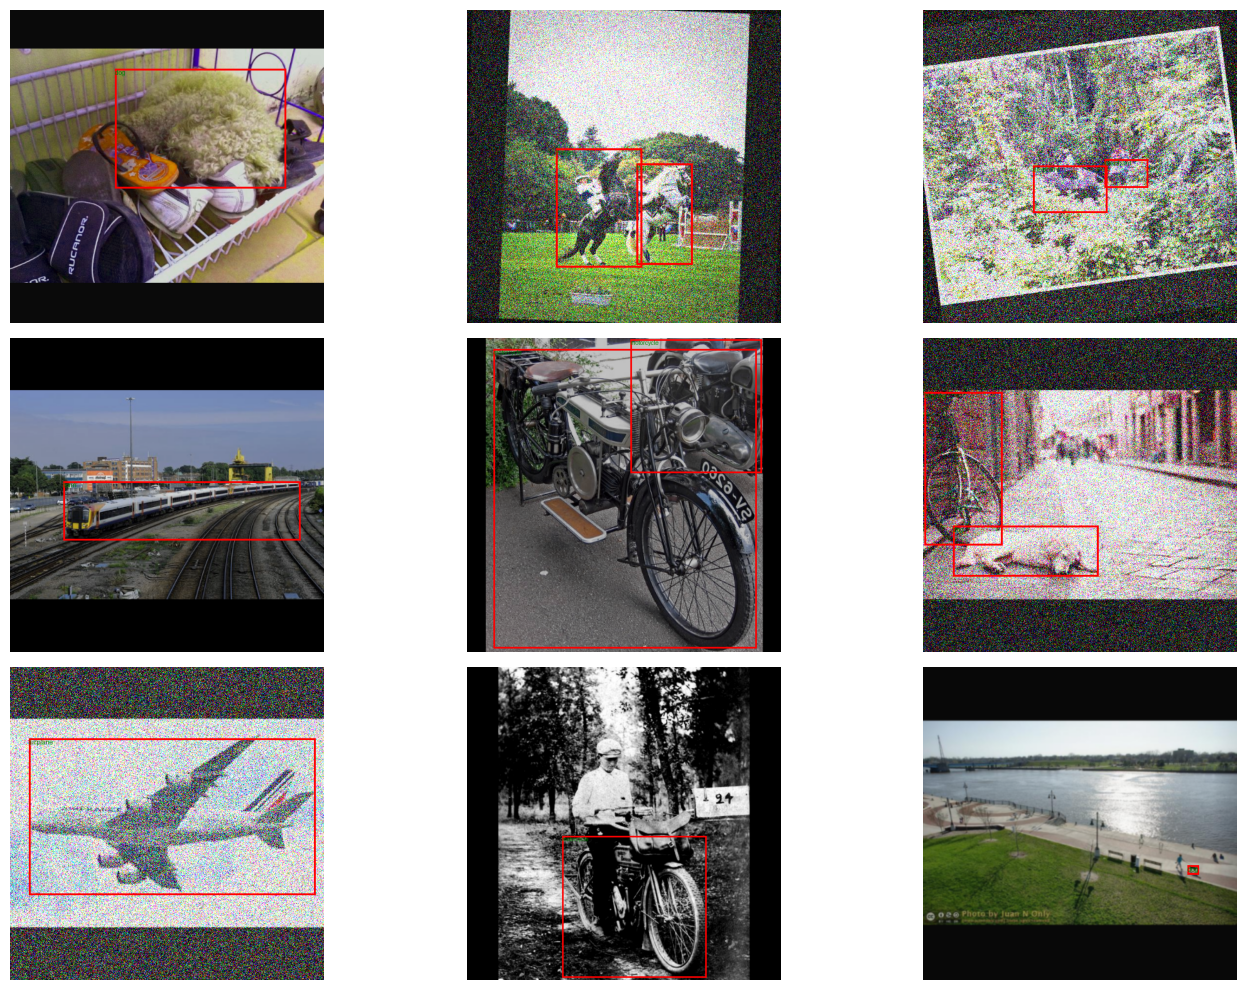

In [16]:
def draw_augmented_image_from_idx(dataset, idx, transform=None):
    sample = dataset[idx]
    image = sample["image"]
    annotations = sample["objects"]

    image = np.array(image.convert("RGB"))[:, :, ::-1]

    if transform:
        augmented = transform(image=image, bboxes=annotations["bbox"], category=annotations["category"])
        image = augmented["image"]
        annotations["bbox"] = augmented["bboxes"]
        annotations["category"] = augmented["category"]

    image = Image.fromarray(image[:, :, ::-1])
    draw = ImageDraw.Draw(image)
    width, height = sample["width"], sample["height"]

    for i in range(len(annotations["bbox_id"])):
        box = annotations["bbox"][i]
        x1, y1, x2, y2 = tuple(box)

        if max(box) <= 1.0:
            x1, y1 = int(x1 * width), int(y1 * height)
            x2, y2 = int(x2 * width), int(y2 * height)
        else:
            x1, y1 = int(x1), int(y1)
            x2, y2 = int(x2), int(y2)

        draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
        draw.text((x1, y1), id2label[annotations["category"][i]], fill="green")

    return image

def plot_augmented_images(dataset, indices, transform=None):
    num_rows = len(indices) // 3
    num_cols = 3
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

    for i, idx in enumerate(indices):
        row = i // num_cols
        col = i % num_cols

        image = draw_augmented_image_from_idx(dataset, idx, transform=transform)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

plot_augmented_images(train_filtred, range(9), transform=train_transform)

# Metrics

In [17]:
def denormalize_boxes(boxes, width, height):
    boxes = boxes.clone()
    boxes[:, 0] *= width
    boxes[:, 1] *= height
    boxes[:, 2] *= width
    boxes[:, 3] *= height
    return boxes

batch_metrics = []
def compute_metrics(eval_pred, compute_result):
    global batch_metrics

    (loss_dict, scores, pred_boxes, last_hidden_state, encoder_last_hidden_state), labels = eval_pred

    image_sizes = []
    target = []

    for label in labels:
        orig_size = label["orig_size"]
        if hasattr(orig_size, "tolist"):
            orig_size = orig_size.tolist()

        if (len(orig_size) == 1):
            width = orig_size[0]
            height = orig_size[0]
        else:
            width = orig_size[0]
            height = orig_size[1]
        
        image_sizes.append((width, height))

        denormalized_boxes = denormalize_boxes(label["boxes"], width, height)
        target.append(
            {
                "boxes": denormalized_boxes,
                "labels": label["class_labels"],
            }
        )

    predictions = []
    for score, box, target_sizes in zip(scores, pred_boxes, image_sizes):
        pred_scores = score[:, :-1]
        pred_scores = softmax(pred_scores, dim=-1)

        width, height = target_sizes
        pred_boxes_abs = denormalize_boxes(box, width, height)
        pred_labels = torch.argmax(pred_scores, dim=-1)
        pred_scores_for_labels = torch.gather(
            pred_scores, 1, pred_labels.unsqueeze(-1)
        ).squeeze(-1)

        predictions.append(
            {
                "boxes": pred_boxes_abs,
                "scores": pred_scores_for_labels,
                "labels": pred_labels,
            }
        )

    metric = MeanAveragePrecision(box_format="xywh", class_metrics=True)

    if not compute_result:
        batch_metrics.append({"preds": predictions, "target": target})
        return {}
    else:
        all_preds, all_targets = [], []
        for batch in batch_metrics:
            all_preds.extend(batch["preds"])
            all_targets.extend(batch["target"])

        metric.update(preds=all_preds, target=all_targets)
        metrics = metric.compute()

        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")

        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
        batch_metrics = []
        return metrics

# Model

## Load model

In [18]:
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

In [19]:
model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta paramet

## Training

In [20]:
output_dir = "detr-resnet-50-dc5-finetuned"

In [21]:
training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    fp16=True,
    save_steps=10000,
    logging_steps=100,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    eval_steps=1000,
    eval_strategy = "steps",
    report_to="tensorboard",
    push_to_hub=False,
    batch_eval_metrics=True,
    no_cuda=False,
    use_cpu=False,
    dataloader_pin_memory=True,
)

In [22]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]

    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels

    return batch

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train,
    eval_dataset=val,
    tokenizer=image_processor,
    compute_metrics=compute_metrics
    load_best_model_at_end=True
)


/tmp/ipykernel_706061/698379240.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [60]:
print(f"Device: {trainer.model.device}")

Device: cuda:0


In [25]:
trainer.train()

Step,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Bicycle,Mar 100 Bicycle,Map Motorcycle,Mar 100 Motorcycle,Map Airplane,Mar 100 Airplane,Map Train,Mar 100 Train,Map Bird,Mar 100 Bird,Map Cat,Mar 100 Cat,Map Dog,Mar 100 Dog,Map Horse,Mar 100 Horse,Map Cow,Mar 100 Cow,Map Elephant,Mar 100 Elephant
1000,2.023300,1.541497,0.001100,0.002700,0.000800,0.000400,0.000900,0.002300,0.033300,0.070500,0.102200,0.038300,0.078300,0.145400,0.001700,0.065200,0.002200,0.271400,0.000000,0.000000,0.000700,0.041600,0.000100,0.053400,0.000100,0.004000,0.002600,0.234900,0.000200,0.054900,0.001700,0.262300,0.001800,0.034500
2000,1.936300,1.473558,0.004100,0.007700,0.003800,0.000800,0.003400,0.007000,0.050400,0.098900,0.151700,0.044700,0.114100,0.237000,0.003300,0.203800,0.007900,0.411600,0.000000,0.000000,0.018100,0.164700,0.000400,0.170700,0.002300,0.019300,0.004200,0.223900,0.001300,0.089000,0.002500,0.186600,0.000600,0.047100
3000,2.115500,1.548915,0.010700,0.019100,0.009400,0.001300,0.005900,0.020600,0.056700,0.104100,0.156500,0.048900,0.108400,0.231200,0.008500,0.177800,0.018700,0.466800,0.004500,0.011900,0.049900,0.321600,0.000200,0.123900,0.000400,0.022300,0.001100,0.040800,0.000200,0.019000,0.004000,0.249500,0.019800,0.131800
4000,1.874800,1.359704,0.016300,0.031200,0.014000,0.002100,0.007000,0.024700,0.087400,0.158100,0.225400,0.056500,0.130500,0.326200,0.003700,0.197200,0.022500,0.522700,0.013200,0.026600,0.069900,0.448900,0.000500,0.199300,0.010900,0.249000,0.003600,0.107800,0.005200,0.141000,0.013100,0.233200,0.020200,0.127800
5000,1.730000,1.368626,0.027900,0.053900,0.024800,0.003900,0.016800,0.041400,0.113300,0.211400,0.290700,0.058000,0.164300,0.412600,0.009000,0.298100,0.034800,0.474100,0.046100,0.242700,0.097800,0.516300,0.000600,0.263900,0.017200,0.395000,0.006400,0.235300,0.017100,0.131100,0.024100,0.221400,0.026000,0.129400
6000,1.798400,1.366176,0.036900,0.064100,0.037100,0.004800,0.017600,0.054300,0.136300,0.245300,0.329700,0.065000,0.185500,0.474200,0.013100,0.285100,0.070600,0.496200,0.042600,0.230800,0.117800,0.567400,0.000700,0.298000,0.022600,0.474300,0.011900,0.216100,0.018300,0.128200,0.029500,0.326200,0.042000,0.275300
7000,1.794600,1.348808,0.030000,0.058300,0.026900,0.006700,0.021000,0.042800,0.120200,0.228900,0.325900,0.061100,0.211100,0.439900,0.009700,0.284200,0.064900,0.432700,0.037500,0.236400,0.064000,0.693200,0.000900,0.284300,0.016400,0.354500,0.015800,0.165600,0.016200,0.138800,0.033100,0.281000,0.041700,0.388600
8000,1.680600,1.294089,0.046100,0.076100,0.045800,0.005400,0.023600,0.064200,0.153500,0.280000,0.407600,0.075700,0.273000,0.560200,0.004700,0.372200,0.049000,0.508100,0.082900,0.445500,0.126700,0.614200,0.001200,0.312300,0.031700,0.488100,0.012200,0.184400,0.048100,0.386100,0.032600,0.338500,0.071700,0.426700
9000,1.764500,1.273318,0.046000,0.079000,0.044200,0.011000,0.033000,0.064100,0.165300,0.296800,0.427000,0.078900,0.322200,0.559000,0.009400,0.311100,0.060800,0.517000,0.070400,0.536400,0.105100,0.723700,0.001000,0.291100,0.036500,0.506900,0.024200,0.233500,0.037300,0.260400,0.023500,0.303500,0.091400,0.586700
10000,1.644800,1.263646,0.048300,0.084600,0.046900,0.011200,0.030600,0.066400,0.161800,0.292900,0.423600,0.087700,0.322500,0.563700,0.015400,0.355100,0.076300,0.450500,0.098900,0.562900,0.101500,0.748400,0.001500,0.320000,0.031300,0.595500,0.006000,0.147700,0.034700,0.208100,0.036000,0.400300,0.081600,0.447500


TrainOutput(global_step=74580, training_loss=1.3962728276844798, metrics={'train_runtime': 29621.4405, 'train_samples_per_second': 10.07, 'train_steps_per_second': 2.518, 'total_flos': 1.4253686903001598e+20, 'train_loss': 1.3962728276844798, 'epoch': 10.0})

## Additional model save

In [26]:
save_dir = "./detr-resnet-50-dc5-finetuned-save"

trainer.save_model(save_dir)
trainer.save_state()
image_processor.save_pretrained(save_dir)

['./detr-resnet-50-dc5-finetuned-save/preprocessor_config.json']

# Error Analysis

## Load model

In [62]:
save_dir = "./detr-resnet-50-dc5-finetuned-save"

image_processor = AutoImageProcessor.from_pretrained(save_dir)
model = AutoModelForObjectDetection.from_pretrained(save_dir)

/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/eboiarnikov/cv-task2/venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta paramet

In [63]:
obj_detector = pipeline(
    "object-detection",
    model=model,
    image_processor=image_processor
)

Device set to use cuda:0


## Missing localization and Classification error matrix

100%|███████████████████████████████████████████████████████████████████████████████| 1247/1247 [01:47<00:00, 11.65it/s]


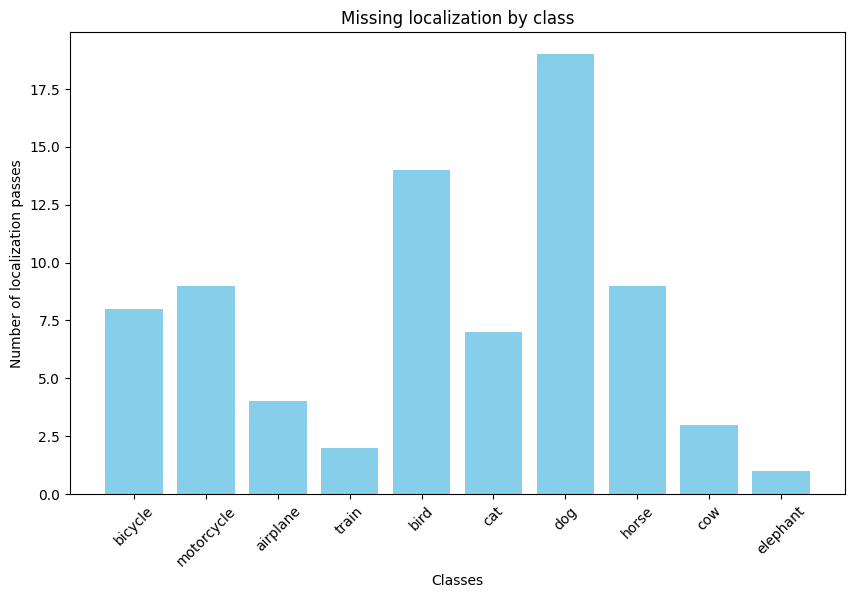

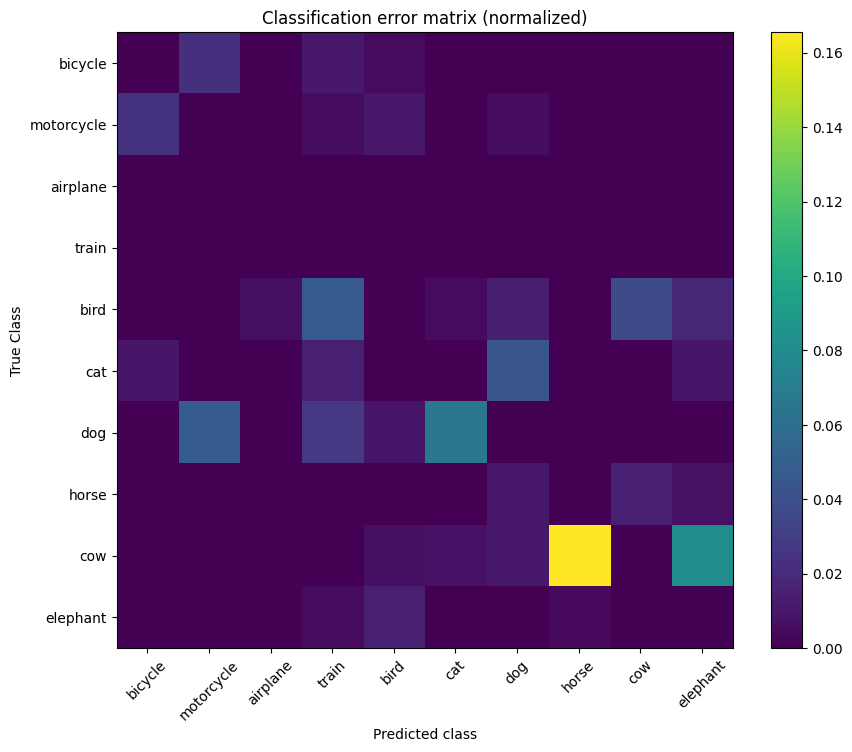

In [64]:
num_classes = len(label2id)

missing_boxes_ids = []
misclassification_ids = []

missing_boxes_by_class = defaultdict(int)
true_class_counts = defaultdict(int)

confusion_matrix = np.zeros((num_classes, num_classes))

for val in tqdm(val_filtred):
    image_id = val['image_id']
    true_classes = val['objects']['category']
    true_bboxes = val['objects']['bbox']
    
    pred = obj_detector(val['image'])
    
    pred_classes = [item['label'] for item in pred]
    pred_bboxes = [item['box'] for item in pred]
    
    true_classes_indices = [cls for cls in true_classes]
    pred_classes_indices = [label2id[cls] for cls in pred_classes]
    
    for cls in true_classes_indices:
        true_class_counts[cls] += 1
    
    if not pred_bboxes:
        missing_boxes_ids.append(image_id)
        for cls in true_classes_indices:
            missing_boxes_by_class[cls] += 1
        continue
    
    misclassified = False
    
    missing_classes = [cls for cls in true_classes_indices if cls not in pred_classes_indices]
    T_missing = len(missing_classes)
    
    extra_classes = [cls for cls in pred_classes_indices if cls not in true_classes_indices]
    T_extra = len(extra_classes)
    
    for true_cls in missing_classes:
        misclassified = True
        for pred_cls in extra_classes:
            confusion_matrix[true_cls, pred_cls] += 1 / T_missing
    
    for pred_cls in extra_classes:
        misclassified = True
        for true_cls in missing_classes:
            confusion_matrix[true_cls, pred_cls] += 1 / T_extra
    
    if misclassified:
        misclassification_ids.append(image_id)

for cls in range(num_classes):
    if true_class_counts[cls] > 0:
        confusion_matrix[cls, :] /= true_class_counts[cls]

plt.figure(figsize=(10, 6))
plt.bar(missing_boxes_by_class.keys(), missing_boxes_by_class.values(), color='skyblue')
plt.xlabel('Classes')
plt.ylabel('Number of localization passes')
plt.title('Missing localization by class')
plt.xticks(range(num_classes), [key for key, value in sorted(label2id.items(), key=lambda x: x[1])], rotation=45)
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(confusion_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.xlabel('Predicted class')
plt.ylabel('True Class')
plt.title('Classification error matrix (normalized)')
plt.xticks(range(num_classes), [key for key, value in sorted(label2id.items(), key=lambda x: x[1])], rotation=45)
plt.yticks(range(num_classes), [key for key, value in sorted(label2id.items(), key=lambda x: x[1])])
plt.show()